## Import Library & Konfigurasi

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from warnings import filterwarnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

filterwarnings('ignore')

# ── Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Konfigurasi Global
DATASET_PATH = './Dataset'   # Sesuaikan jika perlu
CLASSES      = ['lapar', 'normal', 'stress']
SR           = 16000         # Sample rate (Hz)
DURATION     = 2.0           # Durasi audio disamakan (detik)
N_MFCC       = 40            # Jumlah koefisien MFCC
N_FFT        = 512
HOP_LENGTH   = 256
MAX_FRAMES   = int(np.ceil(SR * DURATION / HOP_LENGTH))  # ~125 frames

# Split ratio
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

# Training
BATCH_SIZE = 32
EPOCHS     = 150

print(f'TensorFlow : {tf.__version__}')
print(f'MAX_FRAMES : {MAX_FRAMES}')
print(f'N_FEAT     : {3*N_MFCC} (MFCC + delta + delta2)')
print(f'Dataset    : {os.path.abspath(DATASET_PATH)}')

TensorFlow : 2.21.0
MAX_FRAMES : 125
N_FEAT     : 120 (MFCC + delta + delta2)
Dataset    : c:\S2-Ilmu Komputer 24\Project\Kambing\Notebooks\Dataset


## Eksplorasi Dataset

Distribusi Dataset:
  lapar   :  247 file  (34.4%)
  normal  :  373 file  (52.0%)
  stress  :   97 file  (13.5%)
  Total   :  717 file


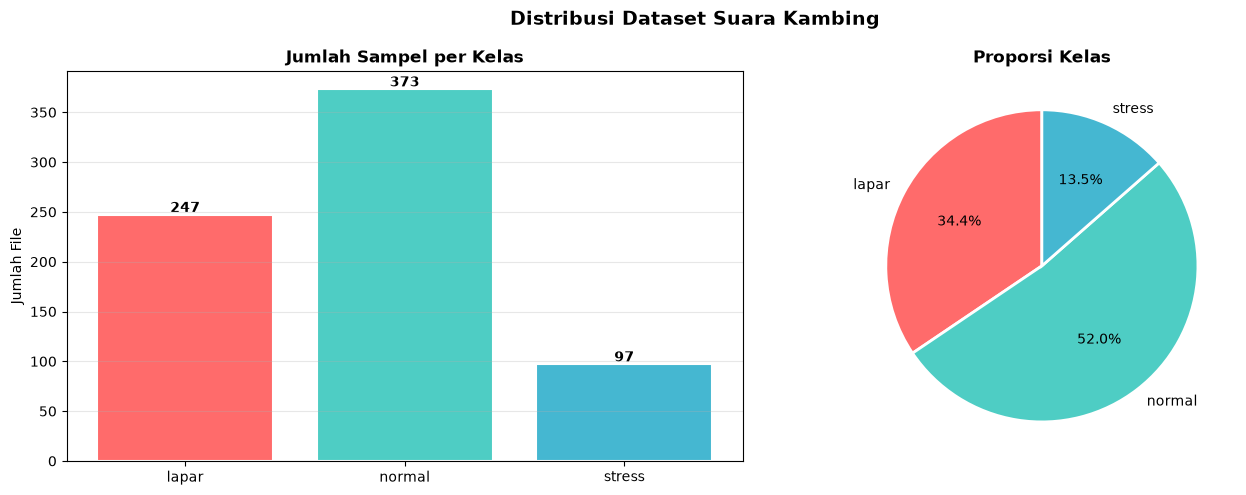

In [4]:
class_counts = {}
all_files    = []

for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    files  = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])
    class_counts[cls] = len(files)
    for f in files:
        all_files.append({'filepath': os.path.join(folder, f), 'label': cls})

df = pd.DataFrame(all_files)

print('Distribusi Dataset:')
for cls, cnt in class_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {cls:<8}: {cnt:>4} file  ({pct:.1f}%)')
print(f'  Total   : {len(df):>4} file')

# Visualisasi
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset Suara Kambing', fontsize=14, fontweight='bold')

bars = axes[0].bar(CLASSES, [class_counts[c] for c in CLASSES],
                   color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Sampel per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah File')
for bar, cnt in zip(bars, [class_counts[c] for c in CLASSES]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(cnt), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([class_counts[c] for c in CLASSES],
            labels=CLASSES, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.tight_layout()
plt.savefig('../Results/distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

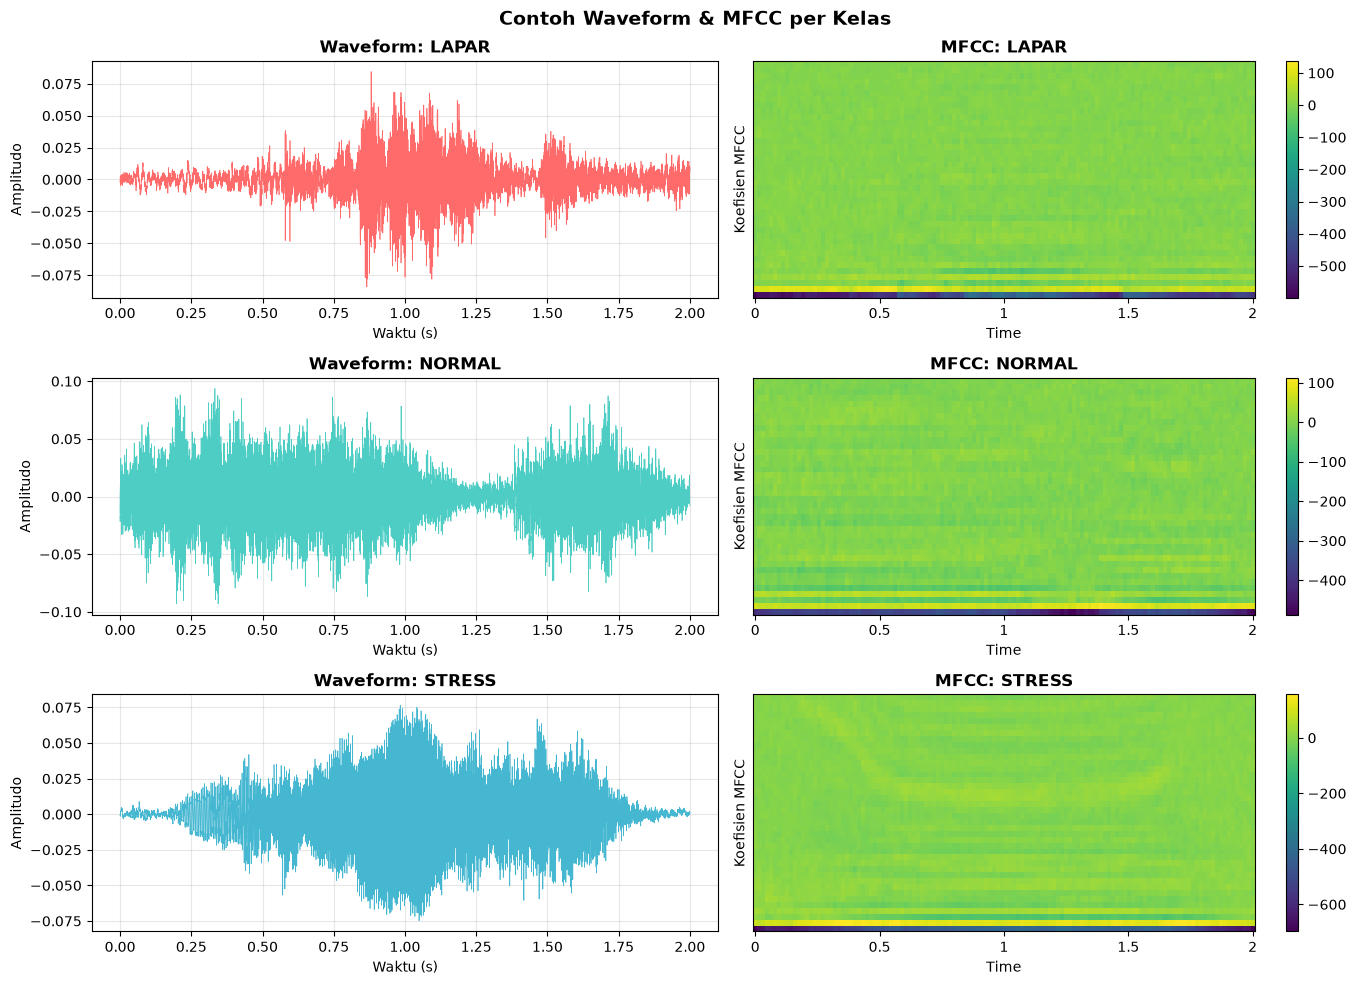

In [5]:
# Visualisasi waveform & MFCC per kelas
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Contoh Waveform & MFCC per Kelas', fontsize=14, fontweight='bold')

for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    sample_path = df[df['label'] == cls]['filepath'].iloc[0]
    y, sr_local = librosa.load(sample_path, sr=SR, duration=DURATION)

    times = np.linspace(0, len(y)/sr_local, len(y))
    axes[i, 0].plot(times, y, color=color, linewidth=0.5)
    axes[i, 0].set_title(f'Waveform: {cls.upper()}', fontweight='bold')
    axes[i, 0].set_xlabel('Waktu (s)')
    axes[i, 0].set_ylabel('Amplitudo')
    axes[i, 0].grid(alpha=0.3)

    mfcc = librosa.feature.mfcc(y=y, sr=sr_local, n_mfcc=N_MFCC,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH)
    img = librosa.display.specshow(mfcc, sr=sr_local, hop_length=HOP_LENGTH,
                                   x_axis='time', ax=axes[i, 1], cmap='viridis')
    axes[i, 1].set_title(f'MFCC: {cls.upper()}', fontweight='bold')
    axes[i, 1].set_ylabel('Koefisien MFCC')
    fig.colorbar(img, ax=axes[i, 1])

plt.tight_layout()
plt.savefig('../Results/waveform_mfcc.png', dpi=150, bbox_inches='tight')
plt.show()

## Ekstraksi Fitur MFCC

**Strategi:**
- **40 koefisien MFCC** + **delta** (velocity) + **delta-delta** (acceleration) = 120 fitur/frame
- Audio di-pad/trim ke panjang `MAX_FRAMES` untuk konsistensi
- Pre-emphasis filter untuk menguatkan frekuensi tinggi
- Normalisasi z-score berdasarkan statistik training set

| Format | Shape | Model |
|--------|-------|-------|
| Flat   | `(N, 240)` | DNN (mean+std per baris) |
| 2D     | `(N, 120, T, 1)` | CNN (MFCC sebagai gambar) |
| Sequence | `(N, T, 120)` | LSTM (urutan temporal) |

In [ ]:
def extract_mfcc_features(filepath, sr=SR, duration=DURATION,
                           n_mfcc=N_MFCC, n_fft=N_FFT,
                           hop_length=HOP_LENGTH, max_frames=MAX_FRAMES):
   
    y, _ = librosa.load(filepath, sr=sr, duration=duration, mono=True)

    # Pastikan panjang konsisten
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='reflect')
    else:
        y = y[:target_len]

    # Pre-emphasis filter
    y = librosa.effects.preemphasis(y)

    # MFCC + delta + delta-delta
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                   n_fft=n_fft, hop_length=hop_length)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    combined = np.vstack([mfcc, delta, delta2])  # (120, frames)

    # Pad/truncate waktu
    if combined.shape[1] < max_frames:
        pad = max_frames - combined.shape[1]
        combined = np.pad(combined, ((0, 0), (0, pad)), mode='constant')
    else:
        combined = combined[:, :max_frames]

    return combined 


# Tes satu file
feat = extract_mfcc_features(df['filepath'].iloc[0])
print(f'Shape satu sampel: {feat.shape}  = ({3*N_MFCC} fitur x {MAX_FRAMES} frames)')

Shape satu sampel: (120, 125)  = (120 fitur x 125 frames)


In [7]:
# Ekstraksi seluruh dataset
print('Mengekstrak fitur MFCC...')
N_FEAT       = 3 * N_MFCC  # 120
all_features = []
all_labels   = []
failed       = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='MFCC'):
    try:
        feat = extract_mfcc_features(row['filepath'])
        all_features.append(feat)
        all_labels.append(row['label'])
    except Exception as e:
        failed.append((row['filepath'], str(e)))

if failed:
    print(f'{len(failed)} file gagal diproses')

X_raw = np.array(all_features)  # (N, 120, MAX_FRAMES)
y_raw = np.array(all_labels)

print(f'X_raw shape: {X_raw.shape}')
print(f'y_raw shape: {y_raw.shape}')

Mengekstrak fitur MFCC...


MFCC: 100%|██████████| 717/717 [00:08<00:00, 81.97it/s]

X_raw shape: (717, 120, 125)
y_raw shape: (717,)


In [8]:
# Label Encoding & Class Weights
le    = LabelEncoder()
le.fit(CLASSES)
y_int = le.transform(y_raw)
y_cat = to_categorical(y_int, num_classes=3)

print('Label mapping:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx} -> {cls}')

# Class weights: atasi imbalance (stress hanya 97 sampel)
cw_arr        = compute_class_weight('balanced',
                                     classes=np.unique(y_int), y=y_int)
class_weights = dict(enumerate(cw_arr))

print('\nClass weights (balanced):')
for idx, w in class_weights.items():
    print(f'  {le.classes_[idx]:<8}: {w:.4f}')

Label mapping:
  0 -> lapar
  1 -> normal
  2 -> stress

Class weights (balanced):
  lapar   : 0.9676
  normal  : 0.6408
  stress  : 2.4639


## Pembagian Dataset

Split **stratified** -> **70% Train | 15% Validation | 15% Test**

Kemudian siapkan 3 format input:

Distribusi split:
  Train      :  501 (69.9%)
  Validation :  108 (15.1%)
  Test       :  108 (15.1%)


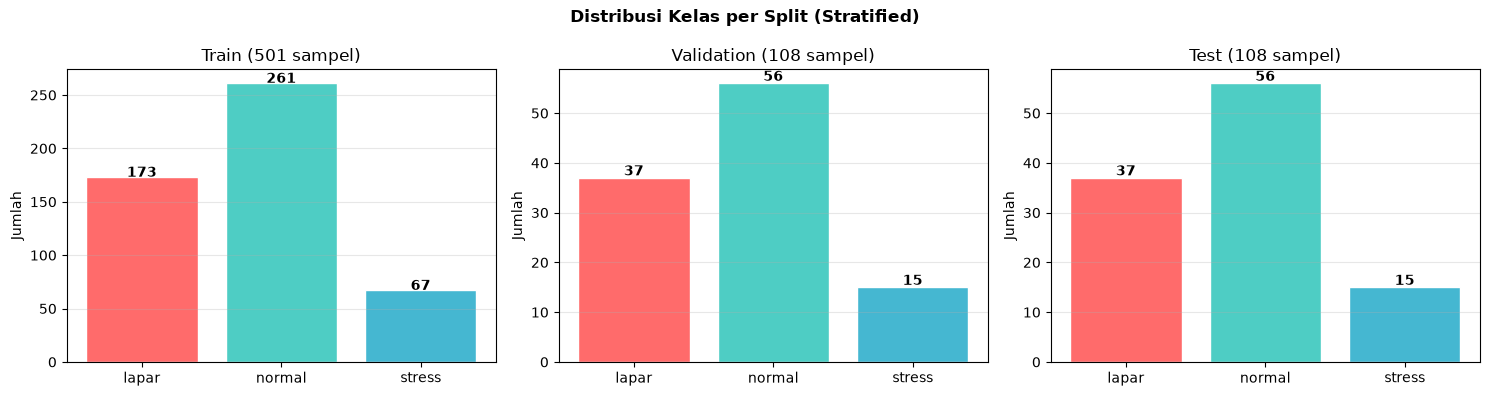

In [9]:
# Split: Test
X_temp, X_test_raw, y_temp_int, y_test_int, y_temp_cat, y_test_cat = train_test_split(
    X_raw, y_int, y_cat,
    test_size=TEST_RATIO, random_state=SEED, stratify=y_int
)

# Split: Train / Val
val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
X_train_raw, X_val_raw, y_train_int, y_val_int, y_train_cat, y_val_cat = train_test_split(
    X_temp, y_temp_int, y_temp_cat,
    test_size=val_ratio_adj, random_state=SEED, stratify=y_temp_int
)

print('Distribusi split:')
print(f'  Train      : {len(X_train_raw):>4} ({len(X_train_raw)/len(X_raw)*100:.1f}%)')
print(f'  Validation : {len(X_val_raw):>4} ({len(X_val_raw)/len(X_raw)*100:.1f}%)')
print(f'  Test       : {len(X_test_raw):>4} ({len(X_test_raw)/len(X_raw)*100:.1f}%)')

# Visualisasi distribusi kelas per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Kelas per Split (Stratified)', fontweight='bold')

for ax, (name, y_split) in zip(axes, [
    ('Train', y_train_int), ('Validation', y_val_int), ('Test', y_test_int)
]):
    unique, counts = np.unique(y_split, return_counts=True)
    ax.bar([le.classes_[u] for u in unique], counts, color=colors, edgecolor='white')
    ax.set_title(f'{name} ({len(y_split)} sampel)')
    ax.set_ylabel('Jumlah')
    for i, (u, c) in enumerate(zip(unique, counts)):
        ax.text(i, c + 0.5, str(c), ha='center', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/distribusi_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Normalisasi global z-score (fit HANYA pada train)
mu_global  = X_train_raw.mean()
sig_global = X_train_raw.std() + 1e-8

X_train_norm = (X_train_raw - mu_global) / sig_global
X_val_norm   = (X_val_raw   - mu_global) / sig_global
X_test_norm  = (X_test_raw  - mu_global) / sig_global

# ── FORMAT 1: FLAT untuk DNN (N, 240) ────────────────────────────────
def to_flat(X):
    mean = X.mean(axis=2)  # (N, 120)
    std  = X.std(axis=2)   # (N, 120)
    return np.hstack([mean, std])  # (N, 240)

X_flat_raw_tr = to_flat(X_train_norm)
X_flat_raw_va = to_flat(X_val_norm)
X_flat_raw_te = to_flat(X_test_norm)

scaler_flat  = StandardScaler()
X_flat_train = scaler_flat.fit_transform(X_flat_raw_tr)
X_flat_val   = scaler_flat.transform(X_flat_raw_va)
X_flat_test  = scaler_flat.transform(X_flat_raw_te)

# ── FORMAT 2: 2D untuk CNN (N, 120, T, 1) ────────────────────────────
X_2d_train = X_train_norm[..., np.newaxis]
X_2d_val   = X_val_norm[..., np.newaxis]
X_2d_test  = X_test_norm[..., np.newaxis]

# ── FORMAT 3: SEQUENCE untuk LSTM (N, T, 120) ────────────────────────
X_seq_train = X_train_norm.transpose(0, 2, 1)
X_seq_val   = X_val_norm.transpose(0, 2, 1)
X_seq_test  = X_test_norm.transpose(0, 2, 1)

print('Input shapes per model:')
print(f'  DNN  (flat) : {X_flat_train.shape}')
print(f'  CNN  (2d)   : {X_2d_train.shape}')
print(f'  LSTM (seq)  : {X_seq_train.shape}')

Input shapes per model:
  DNN  (flat) : (501, 240)
  CNN  (2d)   : (501, 120, 125, 1)
  LSTM (seq)  : (501, 125, 120)


## Fungsi Helper

In [11]:
def plot_history(history, title='Training History', save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train',
                 color='#4ECDC4', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation',
                 color='#FF6B6B', linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',
                 color='#4ECDC4', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation',
                 color='#FF6B6B', linewidth=2, linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test, y_test_int, y_test_cat, label_names,
                   model_name='Model',
                   X_train=None, y_train_cat=None,
                   X_val=None,   y_val_cat=None):
    results = {}
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    test_loss, test_acc    = model.evaluate(X_test, y_test_cat, verbose=0)
    results['test_acc']    = test_acc
    results['test_loss']   = test_loss
    results['f1_macro']    = f1_score(y_test_int, y_pred, average='macro')
    results['f1_weighted'] = f1_score(y_test_int, y_pred, average='weighted')

    if X_train is not None:
        _, tr_acc = model.evaluate(X_train, y_train_cat, verbose=0)
        results['train_acc'] = tr_acc
    if X_val is not None:
        _, va_acc = model.evaluate(X_val, y_val_cat, verbose=0)
        results['val_acc'] = va_acc

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  HASIL EVALUASI: {model_name}')
    print(sep)
    if 'train_acc' in results:
        print(f"  Train Accuracy : {results['train_acc']*100:.2f}%")
    if 'val_acc' in results:
        print(f"  Val Accuracy   : {results['val_acc']*100:.2f}%")
    print(f"  Test Accuracy  : {test_acc*100:.2f}%")
    print(f"  Test Loss      : {test_loss:.4f}")
    print(f"  F1 Macro       : {results['f1_macro']*100:.2f}%")
    print(f"  F1 Weighted    : {results['f1_weighted']*100:.2f}%")
    print(sep)
    print('\nClassification Report:')
    print(classification_report(y_test_int, y_pred, target_names=label_names))

    cm     = confusion_matrix(y_test_int, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, ax2 = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix: {model_name}', fontweight='bold')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax2[0])
    ax2[0].set_title('Jumlah'); ax2[0].set_xlabel('Prediksi'); ax2[0].set_ylabel('Aktual')
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax2[1],
                vmin=0, vmax=100)
    ax2[1].set_title('Persentase (%)'); ax2[1].set_xlabel('Prediksi'); ax2[1].set_ylabel('Aktual')
    plt.tight_layout()
    plt.savefig(f'../Results/cm_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return results


def make_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'../Results/best_{model_name.lower()}.keras',
                        monitor='val_accuracy',
                        save_best_only=True, verbose=0),
    ]

print('Helper functions siap.')

Helper functions siap.


## Model DNN 

**Input shape:** `(N, 240)` yaitu mean + std dari 120 fitur MFCC  
**Arsitektur:** Dense(512) -> Dense(256) -> Dense(128) -> Dense(64) -> Softmax(3)  
Setiap Dense diikuti: BatchNormalization -> ReLU -> Dropout

In [12]:
def build_dnn(input_dim, n_classes=3):
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        # Blok 1
        layers.Dense(512, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        # Blok 2
        layers.Dense(256, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        # Blok 3
        layers.Dense(128, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        # Blok 4
        layers.Dense(64, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        # Output
        layers.Dense(n_classes, activation='softmax'),
    ], name='DNN')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_dnn = build_dnn(X_flat_train.shape[1])
model_dnn.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       123,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,907 (1.14 MB)

 Trainable params: 297,987 (1.14 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
print('Training DNN...')
history_dnn = model_dnn.fit(
    X_flat_train, y_train_cat,
    validation_data=(X_flat_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks('DNN'),
    verbose=1
)

Training DNN...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.4790 - loss: 1.2436 - val_accuracy: 0.5463 - val_loss: 1.0525 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5788 - loss: 0.8651 - val_accuracy: 0.5648 - val_loss: 1.0485 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6307 - loss: 0.7567 - val_accuracy: 0.6111 - val_loss: 0.9701 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7325 - loss: 0.6419 - val_accuracy: 0.6759 - val_loss: 0.8158 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8244 - loss: 0.5228 - val_accuracy: 0.8426 - val_loss: 0.6583 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8483 - loss: 0.4471 - val_accuracy: 0.8611 - val_loss: 0.5212 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8842 - 

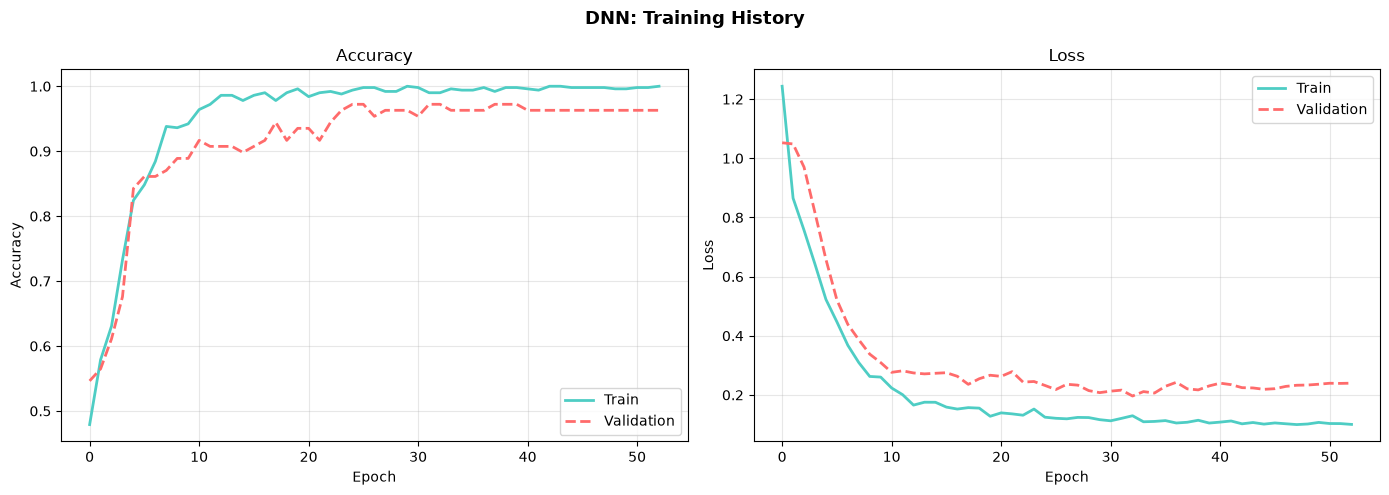


  HASIL EVALUASI: DNN
  Train Accuracy : 100.00%
  Val Accuracy   : 97.22%
  Test Accuracy  : 97.22%
  Test Loss      : 0.1733
  F1 Macro       : 97.78%
  F1 Weighted    : 97.24%

Classification Report:
              precision    recall  f1-score   support

       lapar       0.93      1.00      0.96        37
      normal       1.00      0.95      0.97        56
      stress       1.00      1.00      1.00        15

    accuracy                           0.97       108
   macro avg       0.97      0.98      0.98       108
weighted avg       0.97      0.97      0.97       108



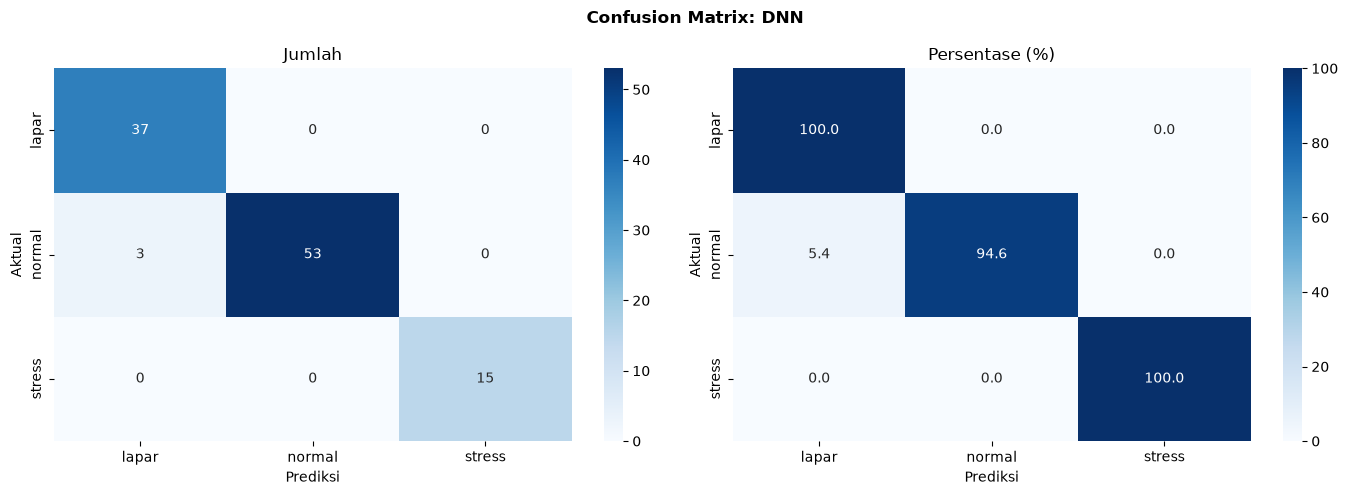

In [ ]:
plot_history(history_dnn, title='DNN: Training History', save_name='../Results/history_dnn.png')
results_dnn = evaluate_model(
    model_dnn, X_flat_test, y_test_int, y_test_cat,
    label_names=CLASSES, model_name='DNN',
    X_train=X_flat_train, y_train_cat=y_train_cat,
    X_val=X_flat_val,     y_val_cat=y_val_cat
)

## Model CNN

**Input shape:** `(N, 120, MAX_FRAMES, 1)` yaitu MFCC sebagai gambar 2D  
**Arsitektur:** 4x [Conv2D -> BN -> ReLU -> MaxPool] -> GlobalAvgPool -> Dense -> Softmax  
CNN efektif menangkap pola lokal pada spektrum frekuensi-waktu.

In [15]:
def build_cnn(input_shape, n_classes=3):
    l2  = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)

    # Blok 1
    x = layers.Conv2D(32,  (3, 3), padding='same', kernel_regularizer=l2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Blok 2
    x = layers.Conv2D(64,  (3, 3), padding='same', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Blok 3
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Blok 4
    x = layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected
    x = layers.Dense(256, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CNN')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_cnn = build_cnn(X_2d_train.shape[1:])
model_cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 125, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 120, 125, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 120, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 120, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 60, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 30, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 490,371 (1.87 MB)

 Trainable params: 488,643 (1.86 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [ ]:
print('Training CNN...')
history_cnn = model_cnn.fit(
    X_2d_train, y_train_cat,
    validation_data=(X_2d_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks('CNN'),
    verbose=1
)

Training CNN...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 533ms/step - accuracy: 0.7265 - loss: 0.6706 - val_accuracy: 0.5185 - val_loss: 1.1356 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.9022 - loss: 0.3219 - val_accuracy: 0.6667 - val_loss: 1.1077 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 402ms/step - accuracy: 0.9162 - loss: 0.2951 - val_accuracy: 0.4630 - val_loss: 1.0927 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 414ms/step - accuracy: 0.9301 - loss: 0.2625 - val_accuracy: 0.4074 - val_loss: 1.0696 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 437ms/step - accuracy: 0.9401 - loss: 0.2273 - val_accuracy: 0.3426 - val_loss: 1.1204 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 433ms/step - accuracy: 0.9541 - loss: 0.1914 - val_accuracy: 0.3426 - val_loss: 1.2244 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - accuracy: 

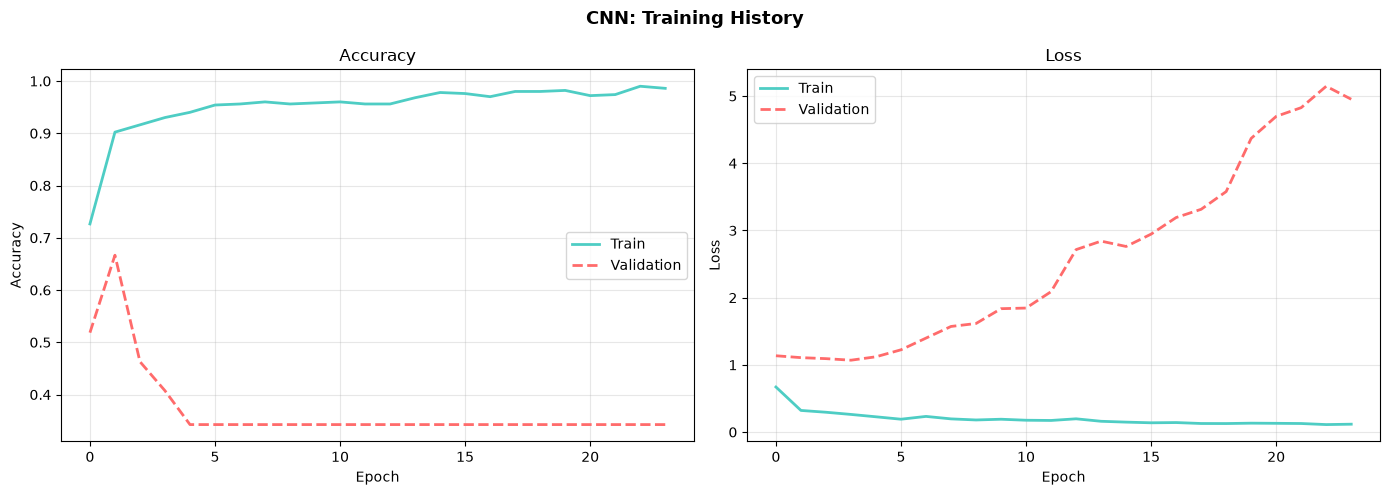


  HASIL EVALUASI: CNN
  Train Accuracy : 40.32%
  Val Accuracy   : 40.74%
  Test Accuracy  : 41.67%
  Test Loss      : 1.0635
  F1 Macro       : 26.34%
  F1 Weighted    : 31.47%

Classification Report:
              precision    recall  f1-score   support

       lapar       0.37      1.00      0.54        37
      normal       1.00      0.14      0.25        56
      stress       0.00      0.00      0.00        15

    accuracy                           0.42       108
   macro avg       0.46      0.38      0.26       108
weighted avg       0.65      0.42      0.31       108



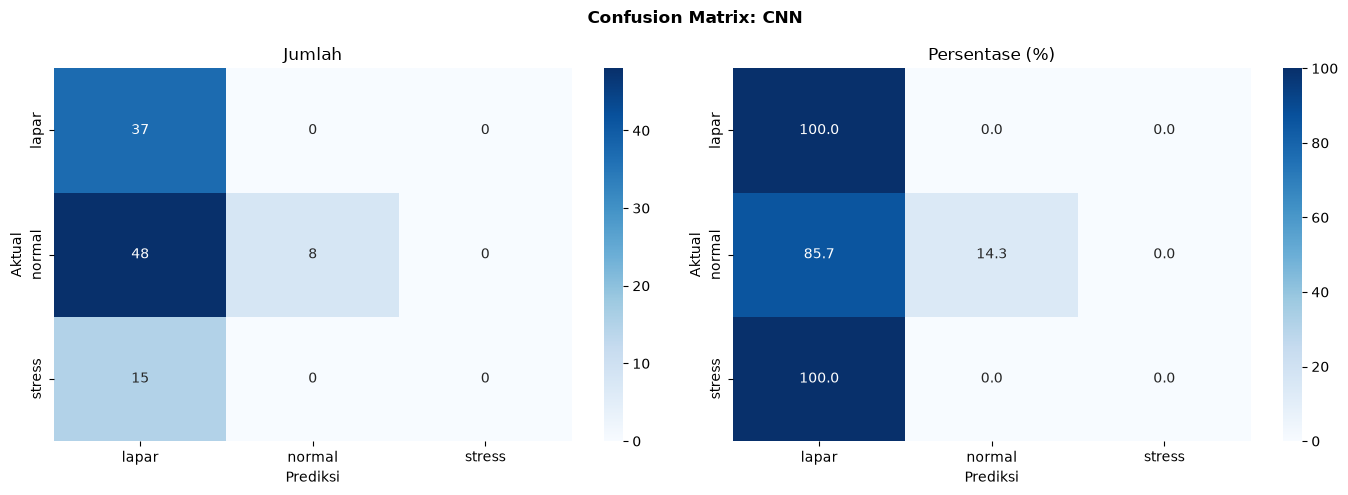

In [ ]:
plot_history(history_cnn, title='CNN: Training History', save_name='../Results/history_cnn.png')
results_cnn = evaluate_model(
    model_cnn, X_2d_test, y_test_int, y_test_cat,
    label_names=CLASSES, model_name='CNN',
    X_train=X_2d_train, y_train_cat=y_train_cat,
    X_val=X_2d_val,     y_val_cat=y_val_cat
)

## Model LSTM 

**Input shape:** `(N, MAX_FRAMES, 120)` yaitu MFCC sebagai urutan temporal  
**Arsitektur:** 3x Bidirectional LSTM -> Dense -> Softmax  
Bidirectional LSTM membaca urutan dari dua arah sehingga konteks lebih kaya.

In [18]:
def build_lstm(input_shape, n_classes=3):
    l2  = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)

    # BiLSTM layer 1
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1,
                    kernel_regularizer=l2)
    )(inp)
    x = layers.BatchNormalization()(x)

    # BiLSTM layer 2
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1,
                    kernel_regularizer=l2)
    )(x)
    x = layers.BatchNormalization()(x)

    # BiLSTM layer 3
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False,
                    dropout=0.2, kernel_regularizer=l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    # Dense layers
    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_lstm = build_lstm(X_seq_train.shape[1:])
model_lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 125, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 125, 256)       │       254,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 125, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,875 (1.83 MB)

 Trainable params: 478,595 (1.83 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [19]:
print('Training LSTM...')
history_lstm = model_lstm.fit(
    X_seq_train, y_train_cat,
    validation_data=(X_seq_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=make_callbacks('LSTM'),
    verbose=1
)

Training LSTM...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 569ms/step - accuracy: 0.4012 - loss: 1.4520 - val_accuracy: 0.4074 - val_loss: 1.2200 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 480ms/step - accuracy: 0.3713 - loss: 1.3970 - val_accuracy: 0.1759 - val_loss: 1.2326 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 489ms/step - accuracy: 0.4072 - loss: 1.3516 - val_accuracy: 0.4444 - val_loss: 1.2228 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 491ms/step - accuracy: 0.3792 - loss: 1.3537 - val_accuracy: 0.4259 - val_loss: 1.2525 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 520ms/step - accuracy: 0.3932 - loss: 1.3523 - val_accuracy: 0.4167 - val_loss: 1.2592 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 512ms/step - accuracy: 0.4391 - loss: 1.2528 - val_accuracy: 0.4352 - val_loss: 1.2532 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 544ms/step - accuracy:

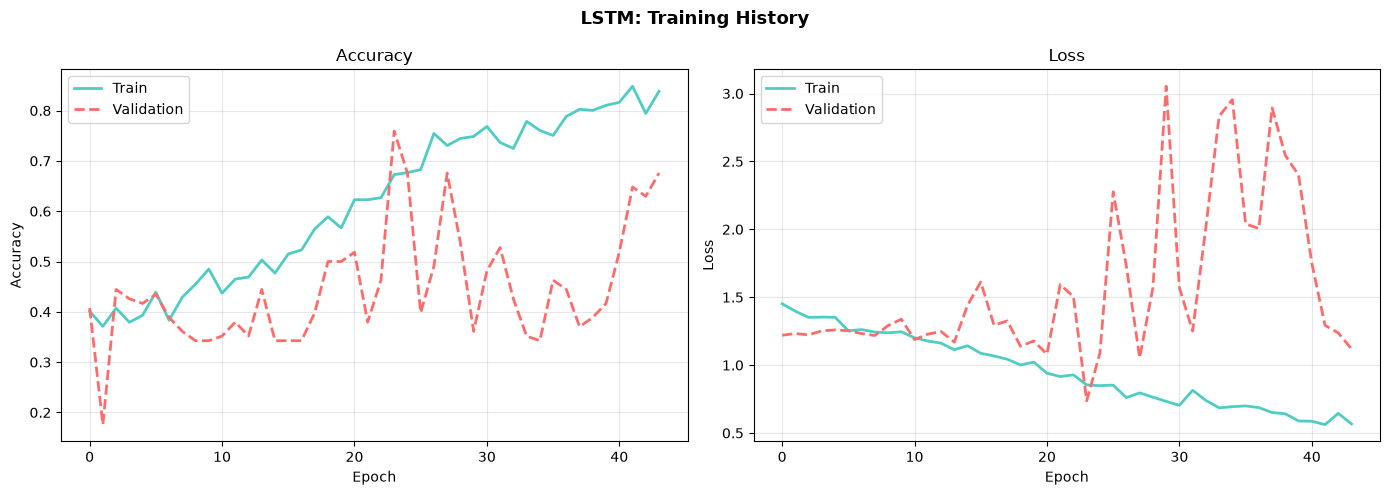


  HASIL EVALUASI: LSTM
  Train Accuracy : 84.43%
  Val Accuracy   : 75.93%
  Test Accuracy  : 84.26%
  Test Loss      : 0.5505
  F1 Macro       : 69.88%
  F1 Weighted    : 81.39%

Classification Report:
              precision    recall  f1-score   support

       lapar       0.74      0.95      0.83        37
      normal       0.91      0.95      0.93        56
      stress       1.00      0.20      0.33        15

    accuracy                           0.84       108
   macro avg       0.89      0.70      0.70       108
weighted avg       0.87      0.84      0.81       108



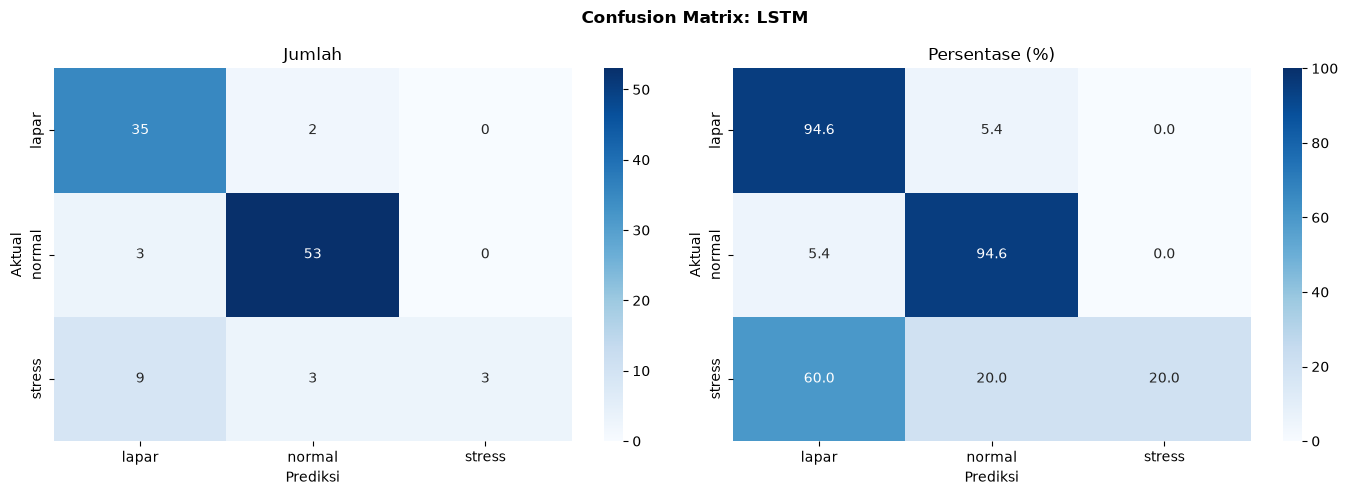

In [20]:
plot_history(history_lstm, title='LSTM: Training History', save_name='../Results/history_lstm.png')
results_lstm = evaluate_model(
    model_lstm, X_seq_test, y_test_int, y_test_cat,
    label_names=CLASSES, model_name='LSTM',
    X_train=X_seq_train, y_train_cat=y_train_cat,
    X_val=X_seq_val,     y_val_cat=y_val_cat
)

## Perbandingan Ketiga Model

In [ ]:
all_results = [('DNN', results_dnn), ('CNN', results_cnn), ('LSTM', results_lstm)]

comparison = {
    'Model'          : ['DNN', 'CNN', 'LSTM'],
    'Train Acc (%)'  : [round(r.get('train_acc', 0)*100, 2) for _, r in all_results],
    'Val Acc (%)'    : [round(r.get('val_acc',   0)*100, 2) for _, r in all_results],
    'Test Acc (%)'   : [round(r['test_acc']*100,         2) for _, r in all_results],
    'F1 Macro (%)'   : [round(r['f1_macro']*100,         2) for _, r in all_results],
    'F1 Weighted (%)': [round(r['f1_weighted']*100,      2) for _, r in all_results],
}
df_comp = pd.DataFrame(comparison).set_index('Model')

sep = '=' * 65
print(sep)
print('  PERBANDINGAN PERFORMA MODEL')
print(sep)
print(df_comp.to_string())
print(sep)

best_name = df_comp['Test Acc (%)'].idxmax()
print(f'Model terbaik: {best_name}')
print(f"  Test Acc : {df_comp.loc[best_name, 'Test Acc (%)']:.2f}%")
print(f"  F1 Macro : {df_comp.loc[best_name, 'F1 Macro (%)']:.2f}%")

  PERBANDINGAN PERFORMA MODEL
       Train Acc (%)  Val Acc (%)  Test Acc (%)  F1 Macro (%)  F1 Weighted (%)
Model                                                                         
DNN           100.00        97.22         97.22         97.78            97.24
CNN            40.32        40.74         41.67         26.34            31.47
LSTM           84.43        75.93         84.26         69.88            81.39
Model terbaik: DNN
  Test Acc : 97.22%
  F1 Macro : 97.78%


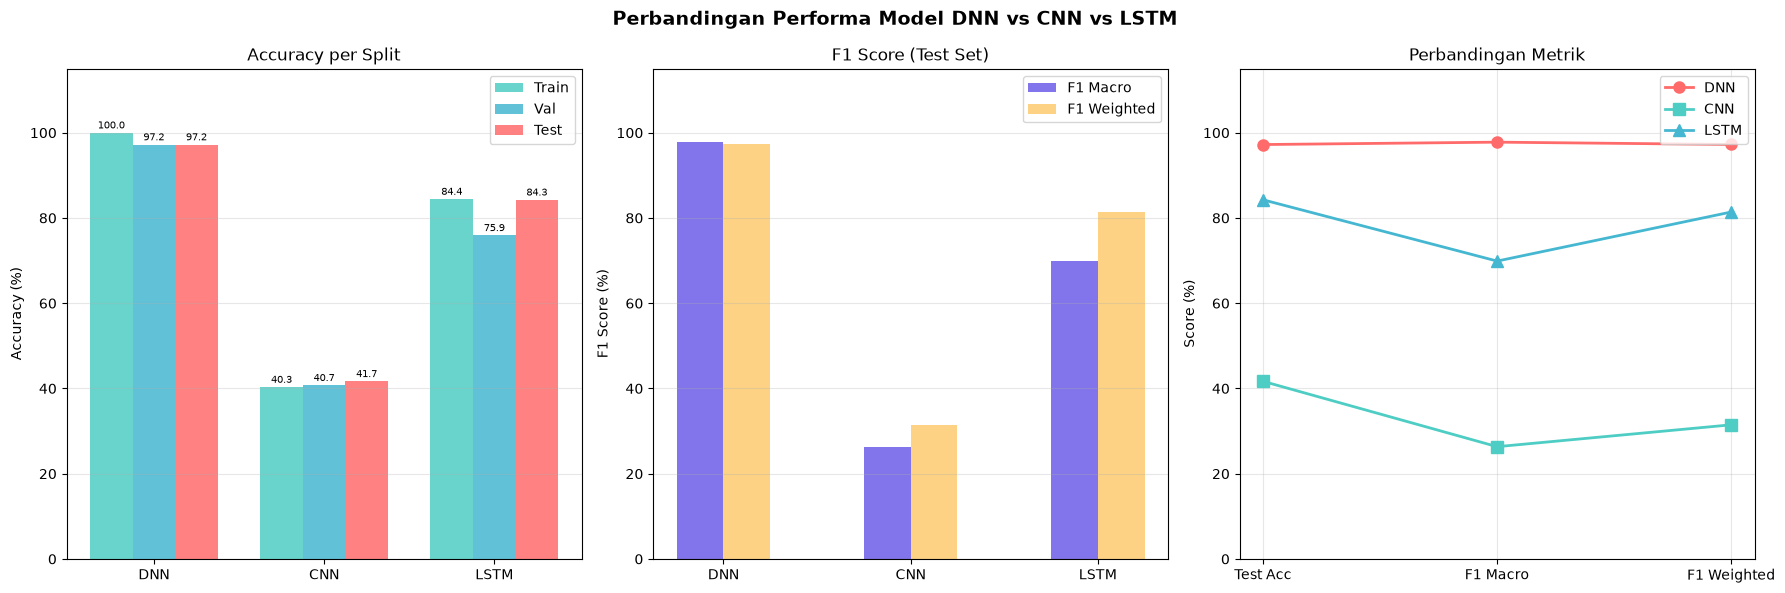

In [ ]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Perbandingan Performa Model DNN vs CNN vs LSTM',
             fontsize=14, fontweight='bold')

model_names = ['DNN', 'CNN', 'LSTM']
x = np.arange(3)
w = 0.25

train_accs = [r.get('train_acc', 0)*100 for _, r in all_results]
val_accs   = [r.get('val_acc',   0)*100 for _, r in all_results]
test_accs  = [r['test_acc']*100          for _, r in all_results]

axes[0].bar(x-w, train_accs, w, label='Train', color='#4ECDC4', alpha=0.85)
axes[0].bar(x,   val_accs,   w, label='Val',   color='#45B7D1', alpha=0.85)
axes[0].bar(x+w, test_accs,  w, label='Test',  color='#FF6B6B', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names)
axes[0].set_title('Accuracy per Split'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].set_ylim(0, 115); axes[0].grid(axis='y', alpha=0.3)
for xi, (tr, va, te) in enumerate(zip(train_accs, val_accs, test_accs)):
    axes[0].text(xi-w, tr+1, f'{tr:.1f}', ha='center', fontsize=7)
    axes[0].text(xi,   va+1, f'{va:.1f}', ha='center', fontsize=7)
    axes[0].text(xi+w, te+1, f'{te:.1f}', ha='center', fontsize=7)

f1m  = [r['f1_macro']*100    for _, r in all_results]
f1w  = [r['f1_weighted']*100 for _, r in all_results]
axes[1].bar(x-w/2, f1m, w, label='F1 Macro',    color='#6C5CE7', alpha=0.85)
axes[1].bar(x+w/2, f1w, w, label='F1 Weighted', color='#FDCB6E', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names)
axes[1].set_title('F1 Score (Test Set)'); axes[1].set_ylabel('F1 Score (%)')
axes[1].legend(); axes[1].set_ylim(0, 115); axes[1].grid(axis='y', alpha=0.3)

m_names = ['Test Acc', 'F1 Macro', 'F1 Weighted']
xi = np.arange(len(m_names))
dnn_s  = [results_dnn['test_acc']*100,  results_dnn['f1_macro']*100,  results_dnn['f1_weighted']*100]
cnn_s  = [results_cnn['test_acc']*100,  results_cnn['f1_macro']*100,  results_cnn['f1_weighted']*100]
lstm_s = [results_lstm['test_acc']*100, results_lstm['f1_macro']*100, results_lstm['f1_weighted']*100]
axes[2].plot(xi, dnn_s,  'o-', color='#FF6B6B', lw=2, ms=8, label='CNN')
axes[2].plot(xi, cnn_s,  's-', color='#4ECDC4', lw=2, ms=8, label='DNN')
axes[2].plot(xi, lstm_s, '^-', color='#45B7D1', lw=2, ms=8, label='LSTM')
axes[2].set_xticks(xi); axes[2].set_xticklabels(m_names)
axes[2].set_title('Perbandingan Metrik'); axes[2].set_ylabel('Score (%)')
axes[2].legend(); axes[2].set_ylim(0, 115); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

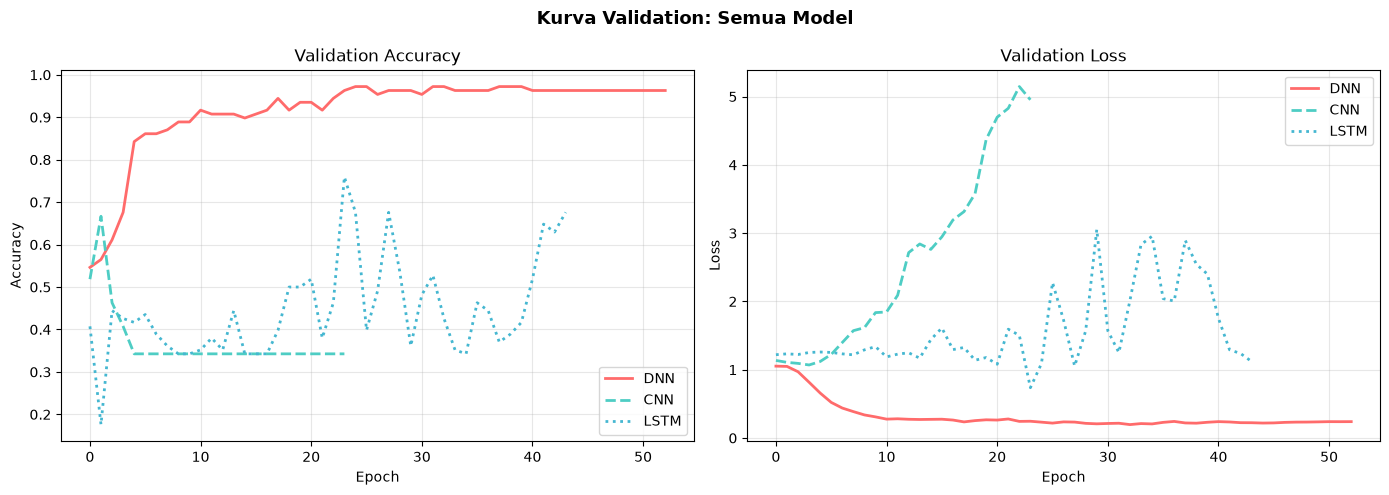

In [ ]:
# Kurva validation semua model dalam satu grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Validation: Semua Model', fontsize=13, fontweight='bold')

for style, color, (name, hist) in zip(
    ['-', '--', ':'], ['#FF6B6B', '#4ECDC4', '#45B7D1'],
    [('DNN', history_dnn), ('CNN', history_cnn), ('LSTM', history_lstm)]
):
    axes[0].plot(hist.history['val_accuracy'], linestyle=style,
                 color=color, linewidth=2, label=name)
    axes[1].plot(hist.history['val_loss'], linestyle=style,
                 color=color, linewidth=2, label=name)

axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/kurva_semua_model.png', dpi=150, bbox_inches='tight')
plt.show()

## Simpan Model

In [ ]:
# # Simpan semua model
# model_dnn.save('../Results/model_dnn_final.keras')
# model_cnn.save('../Results/model_cnn_final.keras')
# model_lstm.save('../Results/model_lstm_final.keras')

# # Simpan model terbaik
# best_name_save, best_res_save = max(all_results, key=lambda x: x[1]['test_acc'])
# model_map = {'DNN': model_dnn, 'CNN': model_cnn, 'LSTM': model_lstm}
# model_map[best_name_save].save(f'../Results/best_model_{best_name_save.lower()}_final.keras')

# print('Semua model disimpan:')
# print('  ../Results/model_dnn_final.keras')
# print('  ../Results/model_cnn_final.keras')
# print('  ../Results/model_lstm_final.keras')
# print(f'  best_model_{best_name_save.lower()}_final.keras  <- Model Terbaik')
# print(f'Best model : {best_name_save}')
# print(f"  Test Acc  : {best_res_save['test_acc']*100:.2f}%")
# print(f"  F1 Macro  : {best_res_save['f1_macro']*100:.2f}%")

Semua model disimpan:
  ../Results/model_dnn_final.keras
  ../Results/model_cnn_final.keras
  ../Results/model_lstm_final.keras
  best_../Results/model_dnn_final.keras  <- Model Terbaik
Best model : DNN
  Test Acc  : 97.22%
  F1 Macro  : 97.78%
